In [17]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    OrdinalEncoder
)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve
)
import matplotlib.pyplot as plt

## ANALISIS DEL CSV

In [18]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

## PREPROCESAMIENTO DE DATOS

In [19]:
df_hotel_prep = df_hotel.copy()

In [20]:
# Remove duplicates
print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

Shape before removing duplicates: (119390, 32)
Duplicated number before: 40165
Shape after removing duplicates: (87396, 32)
Duplicated number after: 0


In [21]:
df_hotel_prep = df_hotel_prep[df_hotel_prep['adr'] >= 0].reset_index(drop=True)

df_hotel_prep = df_hotel_prep[
    df_hotel_prep['adults'].fillna(0) + df_hotel_prep['children'].fillna(0) + df_hotel_prep['babies'].fillna(0) > 0
].reset_index(drop=True)

print(f"Shape tras limpieza de filas inválidas: {df_hotel_prep.shape}")

Shape tras limpieza de filas inválidas: (87229, 32)


In [22]:
# Sustituir valores de niños null con 0 (asumimos null como 0)
print(f"Null values of children before: {df_hotel_prep['children'].isna().sum()}")
df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)
print(f"Null values of children after: {df_hotel_prep['children'].isna().sum()}")

Null values of children before: 4
Null values of children after: 0


In [23]:
# Agrupar los paises con frecuencia < 1%
frequencies = df_hotel_prep['country'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['country'] = np.where(
    df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['country']
)
print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

country
PRT       0.313600
Others    0.119937
GBR       0.119490
FRA       0.101148
ESP       0.083046
DEU       0.061734
ITA       0.035092
IRL       0.034564
BEL       0.023857
BRA       0.022848
NLD       0.021896
USA       0.021449
CHE       0.017953
CN        0.012530
AUT       0.010856
Name: proportion, dtype: float64


In [ ]:
# Agrupar los canales de distribución con frecuencia < 1% — 'Undefined' se conserva como categoría propia
frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['distribution_channel'] = np.where(
    df_hotel_prep['distribution_channel'].isna() | df_hotel_prep['distribution_channel'].isin(index_low_frequency),
    'others',
    df_hotel_prep['distribution_channel']
)
print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

In [ ]:
# Agrupar el segmento de mercado con frecuencia <= 1%
frequencies = df_hotel_prep['market_segment'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['market_segment'] = np.where(
    df_hotel_prep['market_segment'].isna() | df_hotel_prep['market_segment'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['market_segment']
)
print(f"{df_hotel_prep['market_segment'].value_counts(normalize=True)}")

In [26]:
df_hotel_prep['agent_known'] = df_hotel_prep['agent'].notna().astype(int)
df_hotel_prep.drop(columns=['agent'], inplace=True)


In [27]:
drop_columns = [
    'company',
    'arrival_date_year',          # Sobreajusta a años concretos
    'arrival_date_week_number',   # Redundante con mes
    'arrival_date_day_of_month',  # Ruido
    'reservation_status_date',    # Es post-evento, data leakage
    'reservation_status',          # Puede provocar overfitting
]
df_hotel_prep.drop(columns=drop_columns, inplace=True)


In [28]:
MONTHS = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
          'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_hotel_prep['arrival_date_month'] = df_hotel_prep['arrival_date_month'].map(MONTHS)

#### Obtener variables X e y

In [29]:
random_state=11
target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

Percentage y: is_canceled
0    0.724759
1    0.275241
Name: proportion, dtype: float64


In [30]:
model_dtc = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=2, random_state=random_state, class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

# OrdinalEncoder: fit solo con train para evitar leakage
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols]  = encoder.transform(X_test[cat_cols])

print(f"Train data percentage: {y_train.value_counts(normalize=True)}")
print(f"Test data percentage: {y_test.value_counts(normalize=True)}")
model_dtc = model_dtc.fit(X_train, y_train)

Train data percentage: is_canceled
0    0.724761
1    0.275239
Name: proportion, dtype: float64
Test data percentage: is_canceled
0    0.724751
1    0.275249
Name: proportion, dtype: float64


In [31]:
y_predict = model_dtc.predict(X_test)
y_predict_proba = model_dtc.predict_proba(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1-Score:  {f1:.2%}")
print(f"AUC:       {auc:.2%}\n")

Accuracy:  72.10%
Precisión: 49.61%
Recall:    85.38%
F1-Score:  62.75%
AUC:       85.47%



#### Pruerba con RandomizeGridSearchCV

Better parameters
param_dist = {
    'max_iter': [300, 400, 600, 800, 1000],
    'penalty': ['l1'],
    'C': [0.05, 0.1, 0.2, 0.5, 1.0],
    'solver': ['liblinear']
}
multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
refit = 'roc_auc'

In [ ]:
# Random gridsearch
#n_estimators=
#max_depth=4
#min_samples_leaf=
param_dist = {
    'max_depth': [2, 4, 5, 8],
    'min_samples_split': [2, 4, 5, 8],
    'min_samples_leaf': [1, 2, 5, 10]
}
# multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
scoring = 'recall'
# Elijo recall porque quiero atrapar a todos los que pueden cancelar. no quiero falsos negativos
random_gs = RandomizedSearchCV(model_dtc, cv=5, n_iter=20, scoring=scoring, verbose=1, param_distributions=param_dist, random_state=random_state)
random_gs.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {random_gs.best_params_}")
print(f"Mejor puntuación de validación cruzada: {random_gs.best_score_}")
best_model_lr = random_gs.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


#### Prueba con GridSearchCV
Mejor resultado

param_grid = {
    'max_iter': [300, 400, 600, 800, 1000],
    'penalty': ['l1'], # Lasso. No hay muchas columnas
    'C': [0.05, 0.1, 0.2, 0.5, 1.0],
    'solver': ['liblinear']
}
multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
refit = 'roc_auc'

Mejores hiperparámetros: {'C': 1.0, 'max_iter': 300, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación de validación cruzada: 0.7570615093542241


In [ ]:
param_grid = {
    'max_depth': [2, 3, 5, 8],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [1, 2, 5, 8],
    'min_samples_leaf': [1, 3, 5, 7]
}
# multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
scoring = 'recall'
# Elijo recall porque quiero atrapar a todos los que pueden cancelar. no quiero falsos negativos
model_gs = GridSearchCV(model_dtc, cv=5, scoring=scoring, verbose=1, param_grid=param_grid)
model_gs.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {model_gs.best_params_}")
print(f"Mejor puntuación de validación cruzada: {model_gs.best_score_}")
best_model_dtc = model_gs.best_estimator_

Fitting 5 folds for each of 128 candidates, totalling 640 fits


/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
160 fits failed out of a total of 640.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/base.py", line 666, in _validate

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor puntuación de validación cruzada: 0.6220258227483267


In [ ]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_predict))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     12644
           1       0.50      0.85      0.63      4802

    accuracy                           0.72     17446
   macro avg       0.71      0.76      0.70     17446
weighted avg       0.81      0.72      0.74     17446



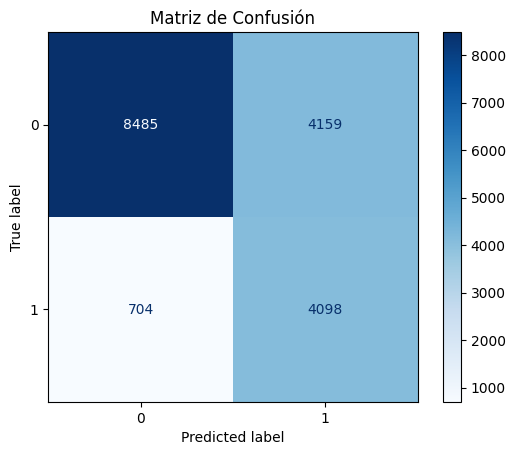

In [ ]:
cm = confusion_matrix(y_test, y_predict)

# 3. Mostrarla de forma visual y bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_dtc.classes_)
disp.plot(cmap='Blues')

plt.title('Matriz de Confusión')
plt.show()

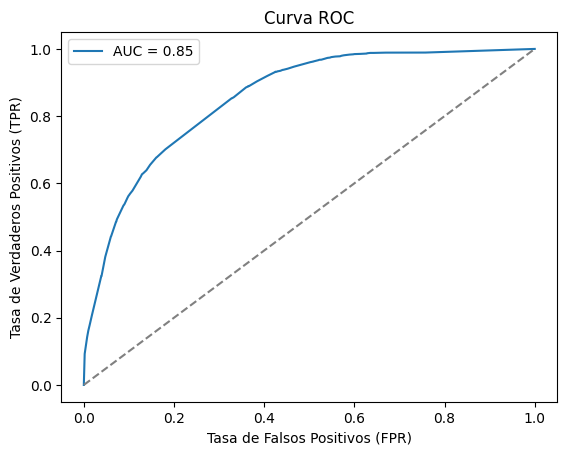

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_predict_proba[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()